In [441]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import iso3166 as iso
from datetime import datetime, timedelta

In [443]:
pd.options.display.float_format = '{:,.2f}'.format

In [445]:
df = pd.read_csv(r"C:\Users\makar\Downloads\Space+Missions+(start)\mission_launches.csv")

In [447]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0.1    4324 non-null   int64  
 1   Unnamed: 0      4324 non-null   int64  
 2   Organisation    4324 non-null   object 
 3   Location        4324 non-null   object 
 4   Date            4324 non-null   object 
 5   Detail          4324 non-null   object 
 6   Rocket_Status   4324 non-null   object 
 7   Price           964 non-null    float64
 8   Mission_Status  4324 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 304.2+ KB


In [449]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success


In [451]:
print("The shape of the data is:", df.shape)

The shape of the data is: (4324, 9)


In [453]:
count_row = df.shape[0]
count_col = df.shape[1]
print("There are", count_row, "rows and", count_col, "columns in this data.")

There are 4324 rows and 9 columns in this data.


In [455]:
print("The column names are:", df.columns)

The column names are: Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')


In [457]:
df.isna()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
4319,False,False,False,False,False,False,False,True,False
4320,False,False,False,False,False,False,False,True,False
4321,False,False,False,False,False,False,False,True,False
4322,False,False,False,False,False,False,False,True,False


In [459]:
clean_df = df.dropna()

In [465]:
df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], inplace=True)
df.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success


In [483]:
desc = df.describe(include='all')
rows_to_drop = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
desc_filtered = desc.drop(rows_to_drop)

desc_filtered

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,4324,4324,4324,4324,4324,964.00,4324
unique,56,137,4319,4278,2,NaN,4
top,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Wed Nov 05, 2008 00:15 UTC",Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,NaN,Success
freq,1777,235,2,6,3534,NaN,3879


In [485]:
df[df['Price'].notna()]['Price'].astype(float).describe()

count     964.00
mean      153.79
std       288.45
min         5.30
25%        40.00
50%        62.00
75%       164.00
max     5,000.00
Name: Price, dtype: float64

In [501]:
launches_per_organisation = df['Organisation'].value_counts()
launches_per_organisation

Organisation
RVSN USSR           1777
Arianespace          279
CASC                 251
General Dynamics     251
NASA                 203
VKS RF               201
US Air Force         161
ULA                  140
Boeing               136
Martin Marietta      114
SpaceX               100
MHI                   84
Northrop              83
Lockheed              79
ISRO                  76
Roscosmos             55
ILS                   46
Sea Launch            36
ISAS                  30
Kosmotras             22
US Navy               17
ISA                   13
Rocket Lab            13
Eurockot              13
ESA                   13
Blue Origin           12
IAI                   11
ExPace                10
ASI                    9
CNES                   8
AMBA                   8
MITT                   7
JAXA                   7
Land Launch            7
UT                     5
KCST                   5
CASIC                  5
Exos                   4
CECLES                 4
Arm??e de l'

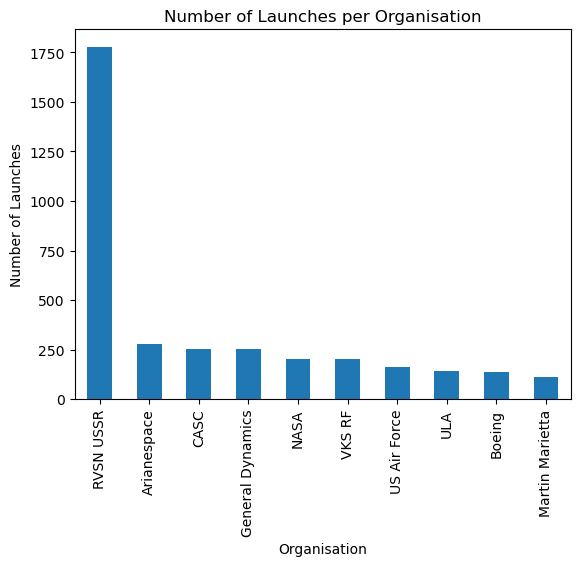

In [511]:
launches_per_organisation[:10].plot(
    kind='bar',
    title='Number of Launches per Organisation'
)

plt.ylabel('Number of Launches')
plt.show()

Cpmparison of the top 10 organisation involved in the space race by amount of rocket launches.

In [513]:
df['Rocket_Status'].value_counts()

Rocket_Status
StatusRetired    3534
StatusActive      790
Name: count, dtype: int64

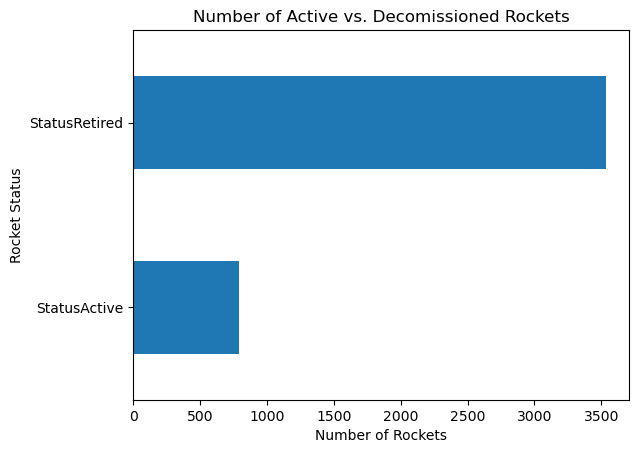

In [515]:
df['Rocket_Status'].value_counts().sort_values().plot(
    kind='barh',
    title='Number of Active vs. Decomissioned Rockets'
)

plt.xlabel('Number of Rockets')
plt.ylabel('Rocket Status')
plt.show()

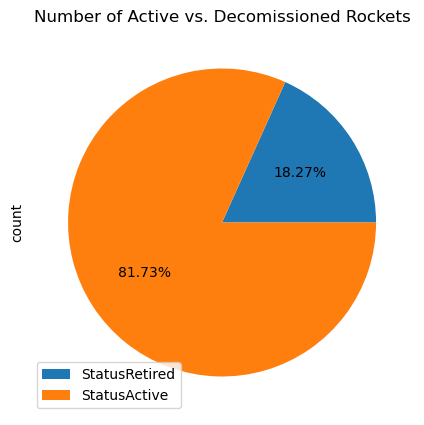

In [521]:
df['Rocket_Status'].value_counts().sort_values().plot(
    kind='pie',
    title='Number of Active vs. Decomissioned Rockets',
    figsize=(5,5),
    autopct='%1.2f%%',
    labels=None
)

plt.legend(labels=df['Rocket_Status'].value_counts().index)
plt.show()

Based on the dataset, as of 2020 there are still 18.27% of rockets still active.

In [307]:
mission_status_df = df['Mission_Status'].value_counts()
mission_status_df

Mission_Status
Success              3879
Failure               339
Partial Failure       102
Prelaunch Failure       4
Name: count, dtype: int64

In [309]:
df.groupby('Mission_Status').agg({'Mission_Status':pd.Series.count})

,Mission_Status
Mission_Status,
Failure,339
Partial Failure,102
Prelaunch Failure,4
Success,3879


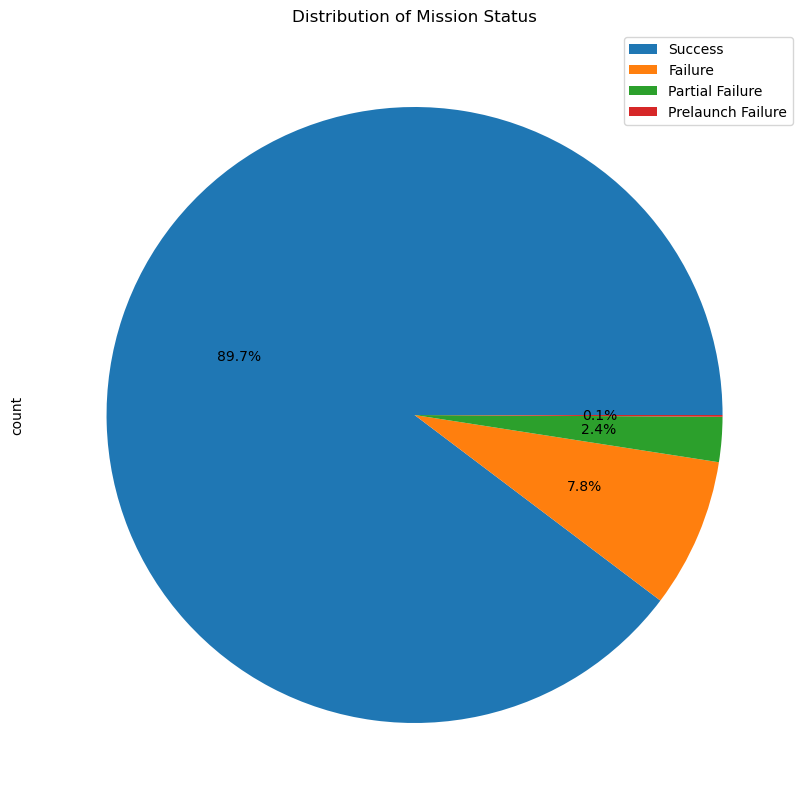

In [311]:
mission_status_df.plot(
    kind='pie',
    figsize=(10,10),
    autopct='%1.1f%%',
    title = 'Distribution of Mission Status',
    labels=None
)

plt.legend(labels=mission_status_df.index)
plt.show()

Based on the dataset, as of 2020 89.7% of missions were launched successfully while only 7.8% were total failures.

In [525]:
cost_of_missions = df['Price'].value_counts()

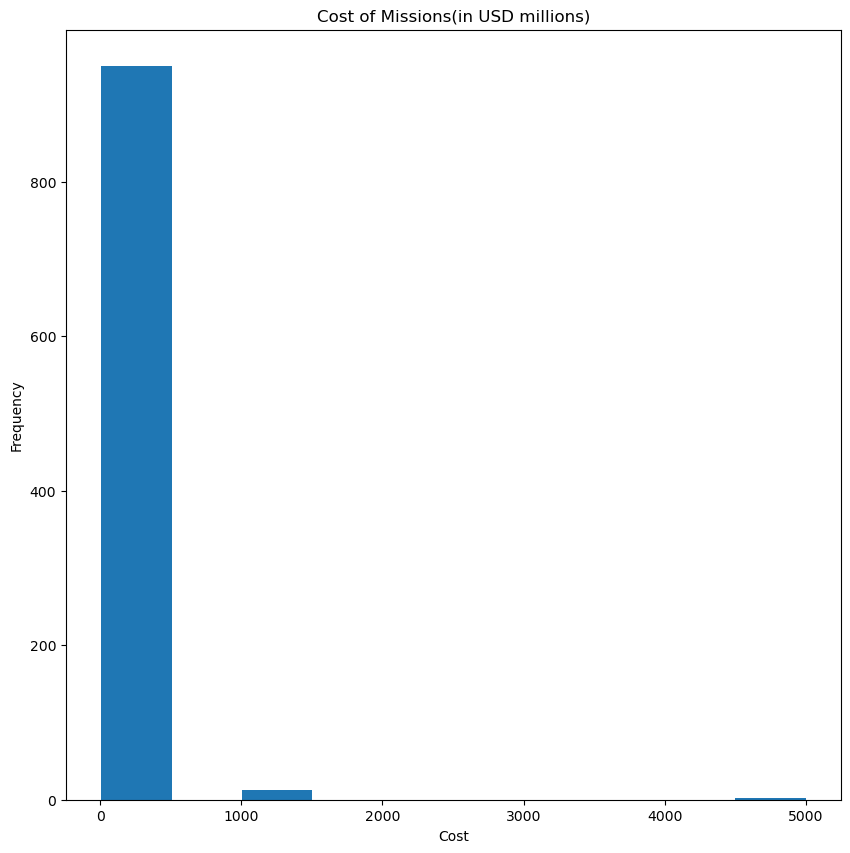

In [529]:
df['Price'].plot(
    kind='hist',
    title='Cost of Missions(in USD millions)',
    figsize=(10,10),
)

plt.xlabel('Cost')
plt.show()

The above histogram shows us that outside of a few outliers the cost of the missions remained fairly consistent.

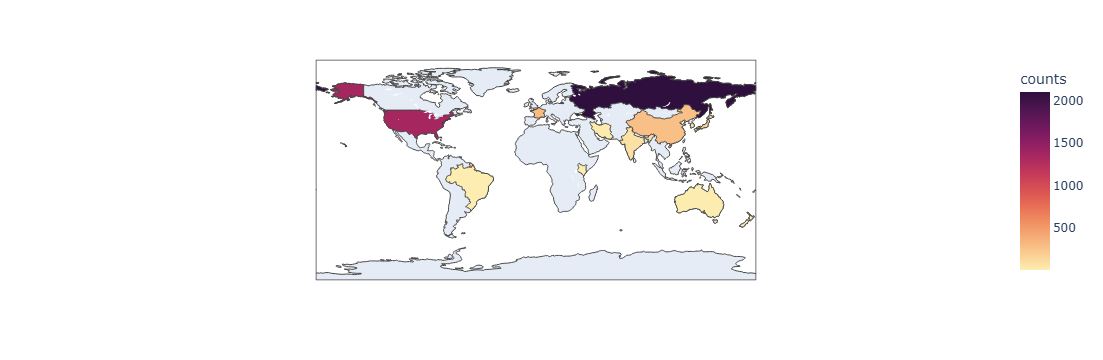

In [543]:
df['Country'] = df['Location'].str.split(', ').str[-1]

df.loc[(df['Country'] == 'Russia'), 'Country'] = 'Russian Federation'
df.loc[(df['Country'] == 'New Mexico'), 'Country'] = 'USA'
df.loc[(df['Country'] == 'Yellow Sea'), 'Country'] = 'China'
df.loc[(df['Country'] == 'Shahrud Missile Test Site'), 'Country'] = 'Iran'
df.loc[(df['Country'] == 'Pacific Missile Range Facility'), 'Country'] = 'USA'
df.loc[(df['Country'] == 'Barents Sea'), 'Country'] = 'Russian Federation'
df.loc[(df['Country'] == 'Gran Canaria'), 'Country'] = 'USA'
df.loc[(df['Country'] == 'Iran'), 'Country'] = 'Iran, Islamic Republic of'
df.loc[(df['Country'] == 'South Korea'), 'Country'] = 'Korea, Republic of'
df.loc[(df['Country'] == 'North Korea'), 'Country'] = 'Korea, Democratic Peoples Republic of'
df.loc[(df['Country'] == 'Kazakhstan'), 'Country'] = 'Russian Federation'

countries = {country.name: key for key, country in iso.countries_by_alpha3.items()}
df = df.replace({'Country': countries})

launches = df['Country'].value_counts().rename_axis('Country').reset_index(name='counts')
launches.head()

world_map = px.choropleth(launches, locations='Country', color='counts', color_continuous_scale=px.colors.sequential.matter)
world_map.update_layout(coloraxis_showscale=True)
world_map.show()

In [547]:
launches = df['Country'].value_counts()
launches

Country
RUS                                      2099
USA                                      1351
FRA                                       303
CHN                                       269
JPN                                       126
IND                                        76
Pacific Ocean                              36
IRN                                        14
NZL                                        13
ISR                                        11
KEN                                         9
AUS                                         6
Korea, Democratic Peoples Republic of       5
KOR                                         3
BRA                                         3
Name: count, dtype: int64

In [263]:
for c in countries:
    print(c)

Afghanistan
Åland Islands
Albania
Algeria
American Samoa
Andorra
Angola
Anguilla
Antarctica
Antigua and Barbuda
Argentina
Armenia
Aruba
Australia
Austria
Azerbaijan
Bahamas
Bahrain
Bangladesh
Barbados
Belarus
Belgium
Belize
Benin
Bermuda
Bhutan
Bolivia, Plurinational State of
Bonaire, Sint Eustatius and Saba
Bosnia and Herzegovina
Botswana
Bouvet Island
Brazil
British Indian Ocean Territory
Brunei Darussalam
Bulgaria
Burkina Faso
Burundi
Cambodia
Cameroon
Canada
Cabo Verde
Cayman Islands
Central African Republic
Chad
Chile
China
Christmas Island
Cocos (Keeling) Islands
Colombia
Comoros
Congo
Congo, Democratic Republic of the
Cook Islands
Costa Rica
Côte d'Ivoire
Croatia
Cuba
Curaçao
Cyprus
Czechia
Denmark
Djibouti
Dominica
Dominican Republic
Ecuador
Egypt
El Salvador
Equatorial Guinea
Eritrea
Estonia
Ethiopia
Falkland Islands (Malvinas)
Faroe Islands
Fiji
Finland
France
French Guiana
French Polynesia
French Southern Territories
Gabon
Gambia
Georgia
Germany
Ghana
Gibraltar
Greece
Greenl

In [537]:
failures_per_country = df[df['Mission_Status'] == 'Failure']['Country'].value_counts()
failures_per_country

Country
RUS                                      135
USA                                      129
CHN                                       19
FRA                                       13
JPN                                       10
IRN                                        8
IND                                        8
Pacific Ocean                              3
Korea, Democratic Peoples Republic of      3
AUS                                        3
NZL                                        2
KOR                                        2
ISR                                        2
BRA                                        2
Name: count, dtype: int64

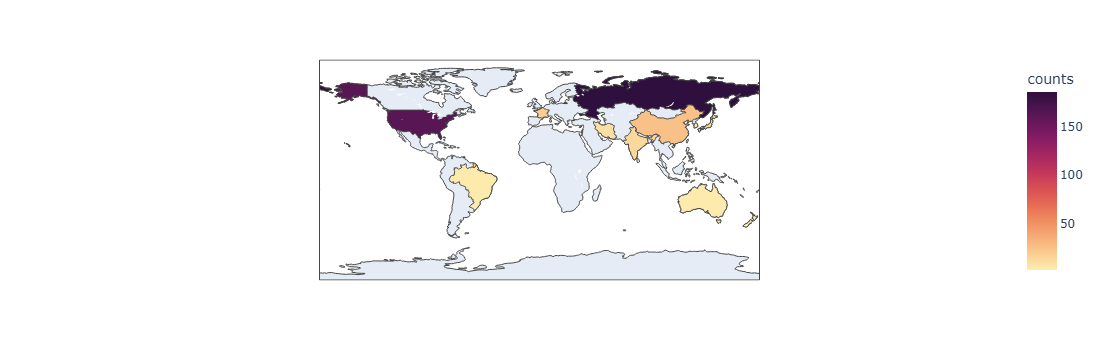

In [265]:
statuses = df.groupby('Country')['Mission_Status'].value_counts().rename_axis(['Country', 'Status']).reset_index(name='counts')
failures = statuses[statuses['Status'].str.contains('Fail')].groupby('Country').sum()

world_map = px.choropleth(failures, locations=failures.index, color='counts', color_continuous_scale=px.colors.sequential.matter)
world_map.update_layout(coloraxis_showscale=True)
world_map.show()

In [539]:
success_per_country = df[df['Mission_Status'] == 'Success']['Country'].value_counts()
success_per_country

Country
RUS                                      1913
USA                                      1188
FRA                                       285
CHN                                       244
JPN                                       113
IND                                        63
Pacific Ocean                              33
NZL                                        11
ISR                                         9
KEN                                         9
IRN                                         5
AUS                                         3
Korea, Democratic Peoples Republic of       2
KOR                                         1
Name: count, dtype: int64

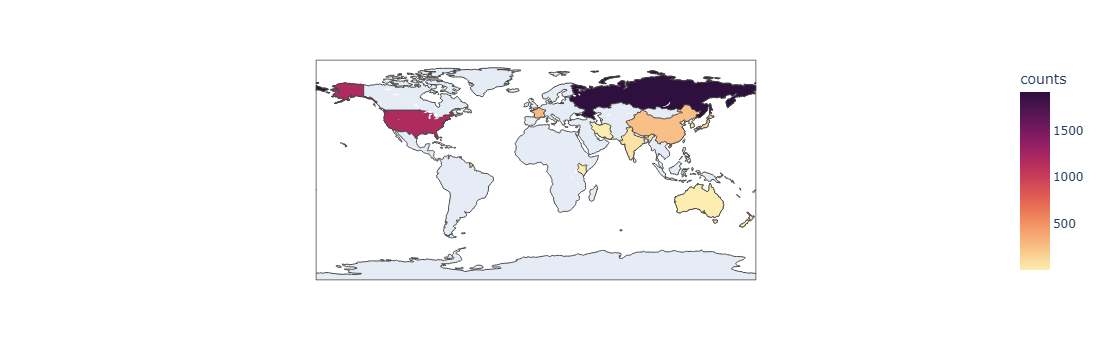

In [541]:
statuses = df.groupby('Country')['Mission_Status'].value_counts().rename_axis(['Country', 'Status']).reset_index(name='counts')
success = statuses[statuses['Status'].str.contains('Success')].groupby('Country').sum()

world_map = px.choropleth(success, locations=success.index, color='counts', color_continuous_scale=px.colors.sequential.matter)
world_map.update_layout(coloraxis_showscale=True)
world_map.show()

Based on the above choropleth maps we can see that the USSR and the USA have the most launches out of any nation and the USSR is leading with the most successful launches to total launches ratio.

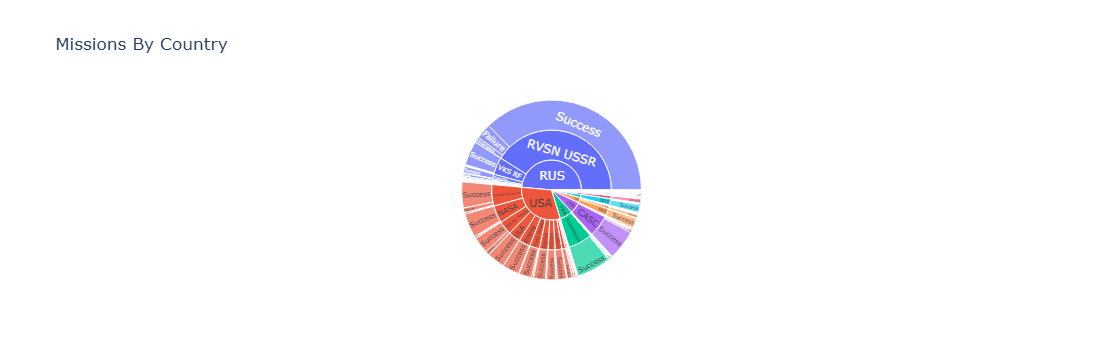

In [267]:
sunburst = df.groupby(by=['Country', 'Organisation', 'Mission_Status'], as_index=False).size()
sunburst = sunburst.sort_values('size', ascending=False)
sunburst.head()
px.sunburst(sunburst, path=['Country', 'Organisation', 'Mission_Status'], values='size', title='Missions By Country')

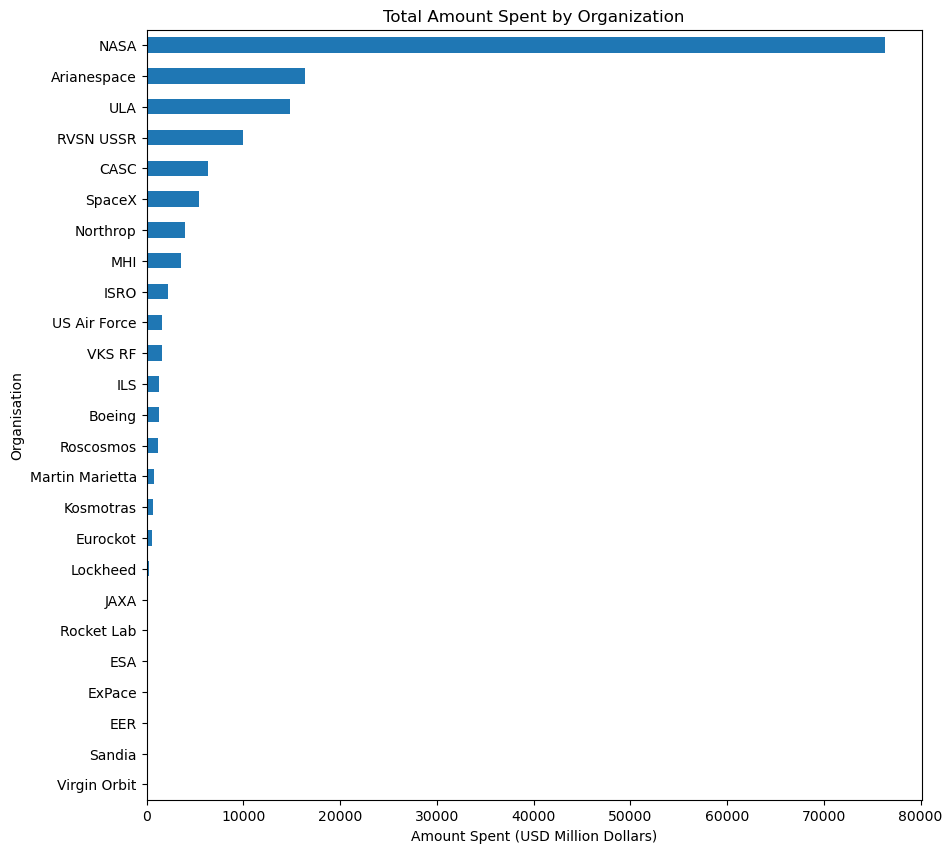

In [593]:
money_spent = df[df['Price'].notna()]

money_spent['Price'] = money_spent['Price'].astype(float)

total_money_spent = money_spent.groupby('Organisation')['Price'].sum()
total_money_spent.sort_values().plot(
    kind='barh',
    title = 'Total Amount Spent by Organization',
    figsize=(10,10)
)
plt.xlabel('Amount Spent (USD Million Dollars)')
plt.ylabel('Organisation')
plt.show()

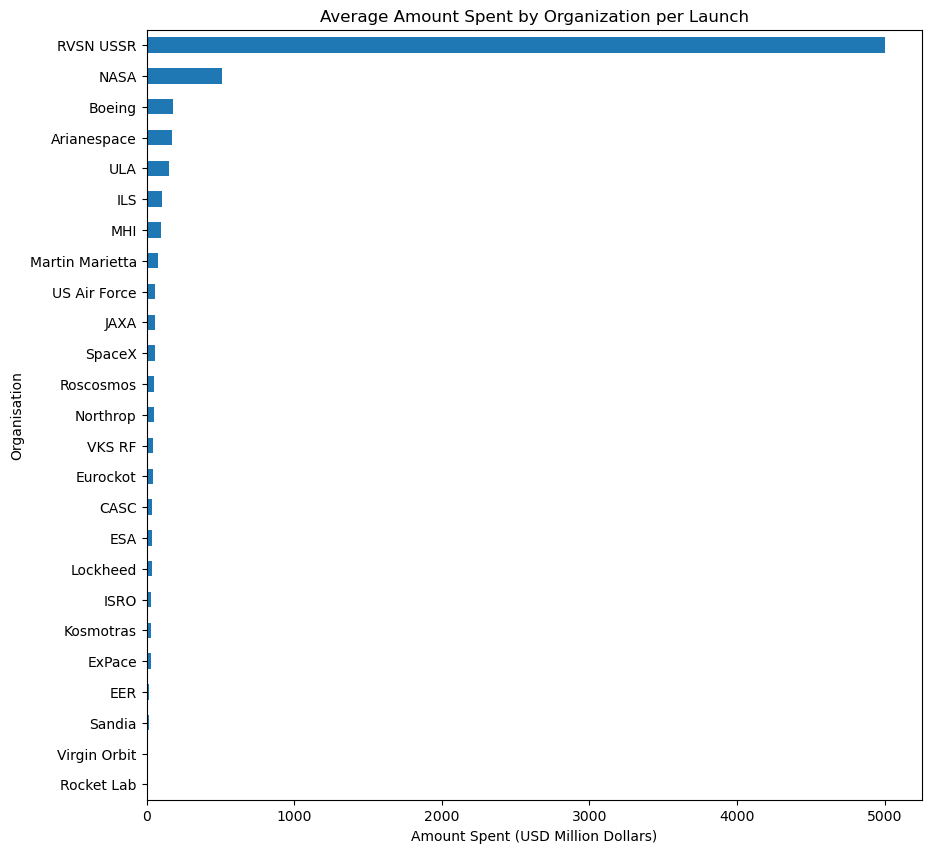

In [597]:
organisation_expense = money_spent.groupby("Organisation")["Price"].mean()
organisation_expense.sort_values().plot(
    kind='barh',
    title = 'Average Amount Spent by Organization per Launch',
    figsize=(10,10)
)
plt.xlabel('Amount Spent (USD Million Dollars)')
plt.ylabel('Organisation')
plt.show()

The above bar charts show us that NASA has accumulated the most overall costs in missions over time while the USSR has the highest average cost per mission. 

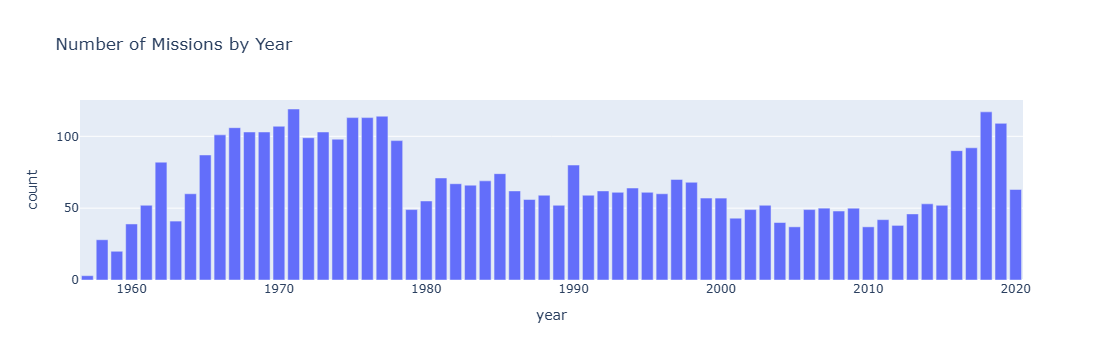

In [599]:
df['date'] = pd.to_datetime(df['Date'], format='mixed', utc=True)
df['year'] = df['date'].apply(lambda datetime: datetime.year)

ds = df['year'].value_counts().reset_index()
ds.columns = [
    'year',
    'count'
]

fig = px.bar(
    ds,
    x='year',
    y='count',
    orientation='v',
    title='Number of Missions by Year'
)
fig.show()

The chart above shows us that the space race peaked for about a decade between the late 60's and 70's before the number of launches per year dropped drastically until it started to come back up around 2016.

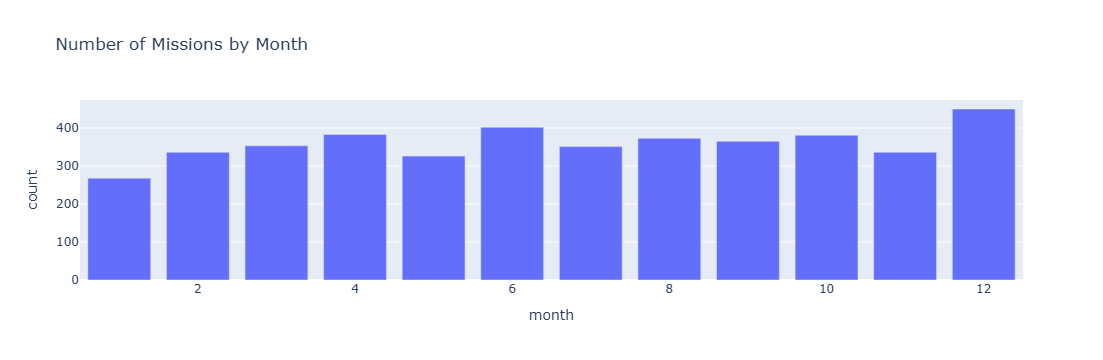

In [601]:
df['date'] = pd.to_datetime(df['Date'], format='mixed', utc=True)
df['month'] = df['date'].apply(lambda datetime: datetime.month)

ds = df['month'].value_counts().reset_index()
ds.columns = [
    'month',
    'count'
]

fig = px.bar(
    ds,
    x='month',
    y='count',
    orientation='v',
    title='Number of Missions by Month'
)
fig.show()

In [277]:
most_launches = ds['count'].max()
print("Most launches in a month =", most_launches)

# print the month associated with the max value
ds.sort_values(by="count", ascending=False)
ds.max()

Most launches in a month = 450


month     12
count    450
dtype: int64

In [279]:
least_launches = ds['count'].min()
print("Least launches in a month =", least_launches)
ds.min()

Least launches in a month = 268


month      1
count    268
dtype: int64

While there aren't any drastic differences between the number of launches on any given month we can see that December is the most preferred month for launching space missions while January is the least popular.

In [619]:
price_over_time = df.dropna().groupby('Date')['Price'].mean()
price_over_time

Date
Fri Apr 04, 1997 16:47 UTC    35.00
Fri Apr 04, 1997 19:20 UTC   450.00
Fri Apr 04, 2014 11:44 UTC    31.00
Fri Apr 05, 1991 14:22 UTC   450.00
Fri Apr 06, 1984 13:58 UTC   450.00
                              ...  
Wed Sep 23, 2009 06:21 UTC    21.00
Wed Sep 23, 2015 21:59 UTC    41.80
Wed Sep 25, 2019 00:54 UTC    29.75
Wed Sep 28, 1966 19:12 UTC    59.00
Wed Sep 30, 2015 20:30 UTC   200.00
Name: Price, Length: 963, dtype: float64

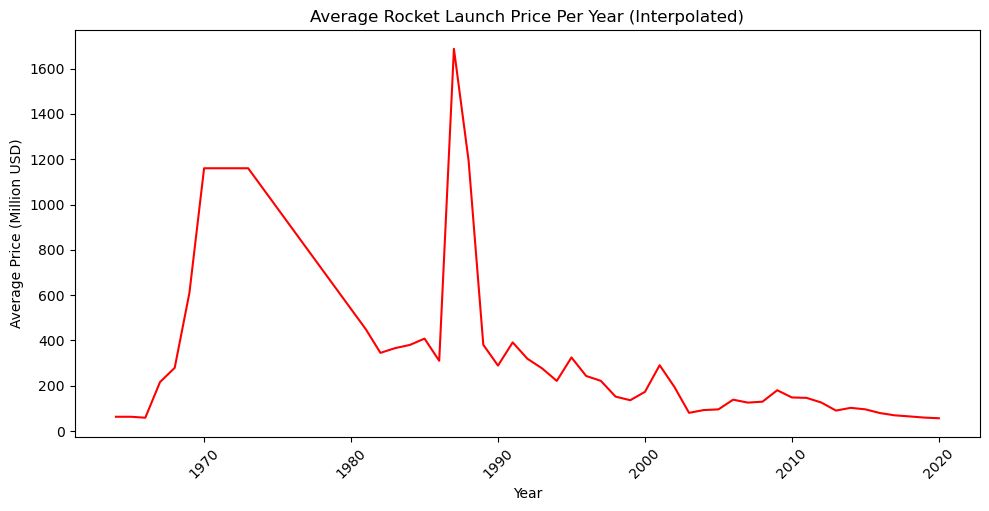

In [667]:
df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce').dt.tz_localize(None)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df_clean = df.dropna(subset=['Date', 'Price'])

df_yearly_avg = df_clean.set_index('Date').resample('YE')['Price'].mean()

full_year_range = pd.date_range(start=df_yearly_avg.index.min(), 
                                end=df_yearly_avg.index.max(), 
                                freq='YE')

df_yearly_filled = df_yearly_avg.reindex(full_year_range)

df_yearly_interp = df_yearly_filled.interpolate(method='linear')

plt.figure(figsize=(10, 5))
plt.plot(df_yearly_interp.index.year, df_yearly_interp.values, linestyle='-', color='red')
plt.title('Average Rocket Launch Price Per Year (Interpolated)')
plt.xlabel('Year')
plt.ylabel('Average Price (Million USD)')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

We can see that the average price per launch peaked in the late 80's and has significantly dropped since then.

In [649]:
top_10_organisations = df['Organisation'].value_counts().sort_values(ascending=False)[:10].index.tolist()
top_10_organisations

['RVSN USSR',
 'Arianespace',
 'CASC',
 'General Dynamics',
 'NASA',
 'VKS RF',
 'US Air Force',
 'ULA',
 'Boeing',
 'Martin Marietta']

In [333]:
launches_by_top_10 = df[df['Organisation'].isin(top_10_organisations)].groupby(['year', 'Organisation'])['Detail'].count().unstack(level=1)
launches_by_top_10.fillna(0, inplace=True) 
launches_by_top_10

Organisation,Arianespace,Boeing,CASC,General Dynamics,Martin Marietta,NASA,RVSN USSR,ULA,US Air Force,VKS RF
year,,,,,,,,,,
1957,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,0.00
1958,0.00,0.00,0.00,0.00,0.00,2.00,5.00,0.00,2.00,0.00
1959,0.00,0.00,0.00,1.00,0.00,1.00,4.00,0.00,10.00,0.00
1960,0.00,0.00,0.00,5.00,0.00,4.00,9.00,0.00,21.00,0.00
1961,0.00,0.00,0.00,8.00,0.00,12.00,9.00,0.00,23.00,0.00
...,...,...,...,...,...,...,...,...,...,...
2016,11.00,0.00,22.00,0.00,0.00,0.00,0.00,12.00,0.00,4.00
2017,11.00,0.00,16.00,0.00,0.00,0.00,0.00,8.00,0.00,6.00
2018,11.00,0.00,37.00,0.00,0.00,0.00,0.00,8.00,0.00,5.00


RVSN USSR
Arianespace
CASC
General Dynamics
NASA
VKS RF
US Air Force
ULA
Boeing
Martin Marietta


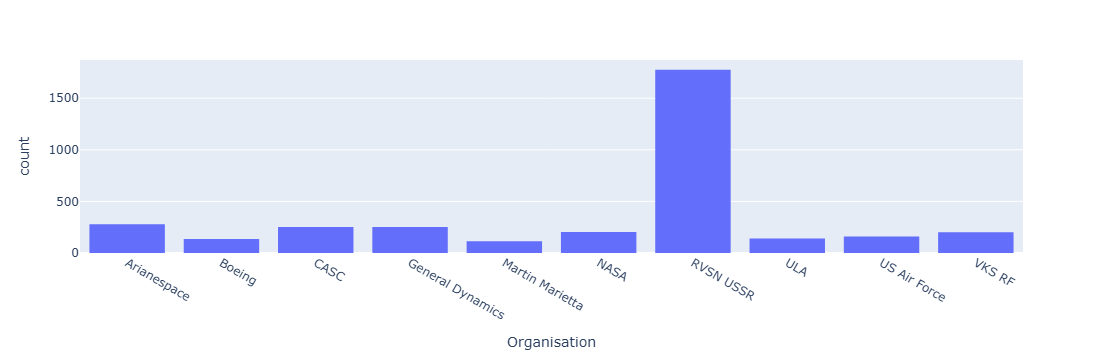

In [675]:
top_10_list = []

for val in df.groupby("Organisation").count().sort_values("Date", ascending=False)[:10].index:
    print(val)
    org = df[df.Organisation == val]
    top_10_list.append(org)

top_10 = pd.concat(top_10_list, ignore_index=False)

df[df.Organisation == "CASC"]

top_10.groupby("Organisation").count().sort_values("Date", ascending=False)[:10].index

px.histogram(
    top_10.sort_values(by=["Organisation", "Date"], ascending=[True, False]),
    x="Organisation",
    nbins=10
)

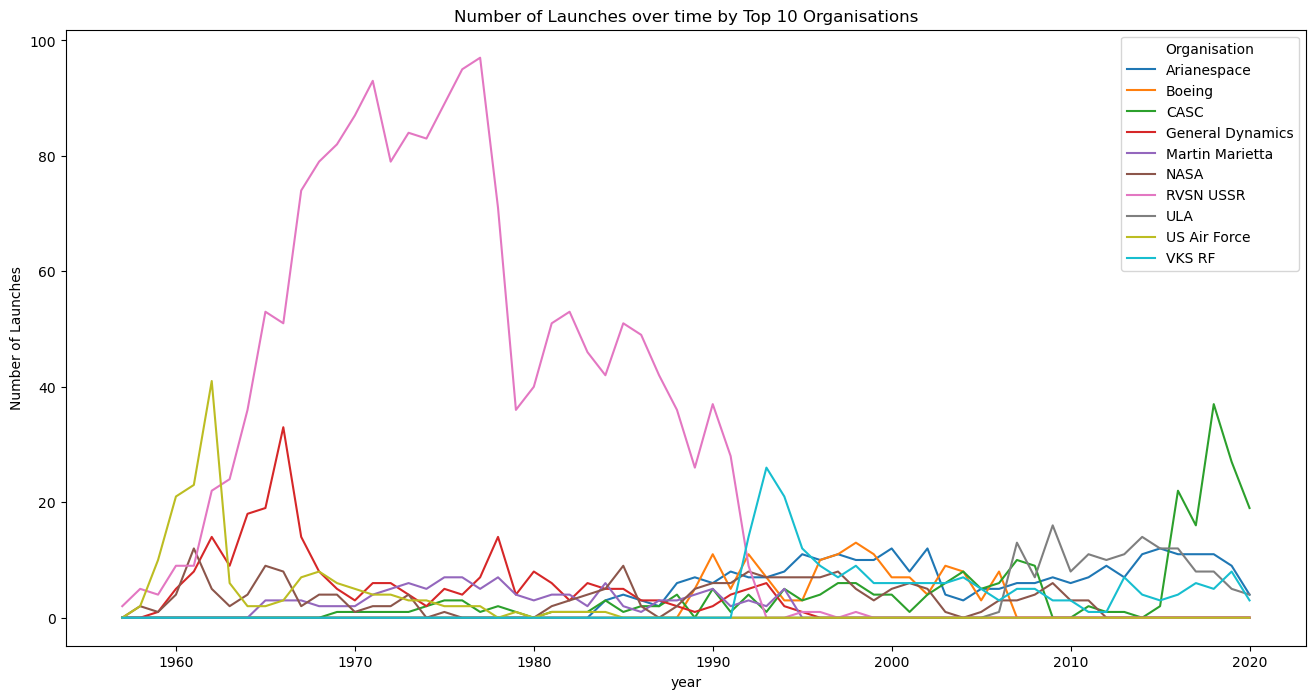

In [335]:
launches_by_top_10.plot(
    figsize=(16,8),
    title = 'Number of Launches over time by Top 10 Organisations',
)

plt.ylabel('Number of Launches')
plt.show()

We can see that while the USSR is leading with the highest count of missions for any single organisations that their dominance in the space race has dropped of towards the end of the 20th century with other organisations such as CASC picking up the lead.

In [677]:
cold_war_df = df[df['year']<=1991].sort_values('year').reset_index(drop=True)

In [679]:
cold_war_df.shape

(2607, 11)

In [681]:
cold_war_df.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,date,year,month
0,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-10-04 19:28:00,Sputnik 8K71PS | Sputnik-1,StatusRetired,NaN,Success,RUS,1957-10-04 19:28:00+00:00,1957,10
1,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-11-03 02:30:00,Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success,RUS,1957-11-03 02:30:00+00:00,1957,11
2,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1957-12-06 16:44:00,Vanguard | Vanguard TV3,StatusRetired,NaN,Failure,USA,1957-12-06 16:44:00+00:00,1957,12
3,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01 03:48:00,Juno I | Explorer 1,StatusRetired,NaN,Success,USA,1958-02-01 03:48:00+00:00,1958,2
4,US Air Force,"LC-11, Cape Canaveral AFS, Florida, USA",1958-12-18 23:02:00,SM-65B Atlas | SCORE,StatusRetired,NaN,Success,USA,1958-12-18 23:02:00+00:00,1958,12


In [683]:
for country in cold_war_df['Country'].drop_duplicates():
  print(countries.get(country))

None
None
None
None
None
None
None
None
None


In [687]:
cold_war_df['Country'] = cold_war_df['Country'].replace({'KAZ': 'RUS'})
cold_war_df['Country'].value_counts()

Country
RUS    1770
USA     662
FRA      61
JPN      52
CHN      38
KEN       9
IND       7
AUS       6
ISR       2
Name: count, dtype: int64

In [353]:
ussr_vs_usa = cold_war_df[cold_war_df['Country'].isin(['RUS','USA'])]
ussr_vs_usa

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,date,year,month
0,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Fri Oct 04, 1957 19:28 UTC",Sputnik 8K71PS | Sputnik-1,StatusRetired,NaN,Success,RUS,1957-10-04 19:28:00+00:00,1957,10
1,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success,RUS,1957-11-03 02:30:00+00:00,1957,11
2,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure,USA,1957-12-06 16:44:00+00:00,1957,12
3,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success,USA,1958-02-01 03:48:00+00:00,1958,2
4,US Air Force,"LC-11, Cape Canaveral AFS, Florida, USA","Thu Dec 18, 1958 23:02 UTC",SM-65B Atlas | SCORE,StatusRetired,NaN,Success,USA,1958-12-18 23:02:00+00:00,1958,12
...,...,...,...,...,...,...,...,...,...,...,...
2601,RVSN USSR,"Site 32/2, Plesetsk Cosmodrome, Russia","Tue Jun 04, 1991 09:00 UTC",Tsyklon-3 | Okean 3,StatusRetired,NaN,Success,RUS,1991-06-04 09:00:00+00:00,1991,6
2602,NASA,"LC-39B, Kennedy Space Center, Florida, USA","Wed Jun 05, 1991 13:24 UTC",Space Shuttle Columbia | STS-40,StatusRetired,450.00,Success,USA,1991-06-05 13:24:00+00:00,1991,6
2603,RVSN USSR,"Site 133/3, Plesetsk Cosmodrome, Russia","Tue Jun 11, 1991 05:42 UTC",Cosmos-3M (11K65M) | Cosmos 2150,StatusRetired,NaN,Success,RUS,1991-06-11 05:42:00+00:00,1991,6
2604,RVSN USSR,"Site 32/2, Plesetsk Cosmodrome, Russia","Thu Jun 13, 1991 15:41 UTC",Tsyklon-3 | Cosmos 2151,StatusRetired,NaN,Success,RUS,1991-06-13 15:41:00+00:00,1991,6


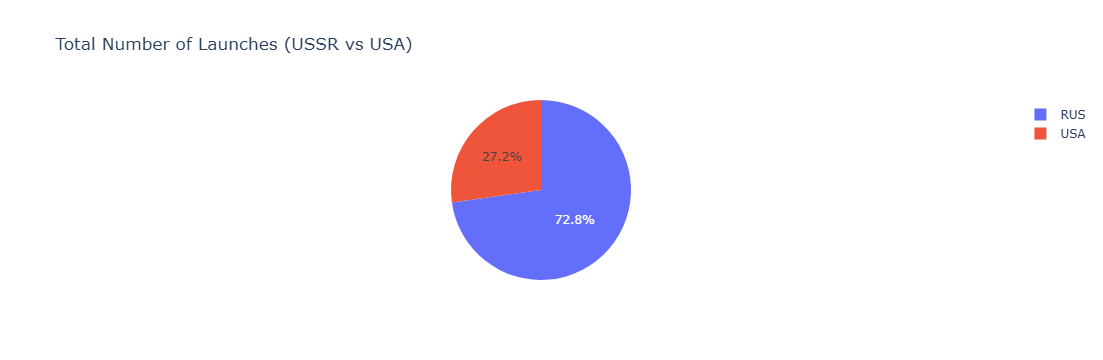

In [355]:
px.pie(
    title = 'Total Number of Launches (USSR vs USA)',
    values = ussr_vs_usa['Country'].value_counts(),
    names = ussr_vs_usa['Country'].value_counts().index,
)

In [359]:
cold_war_launch_by_year = ussr_vs_usa.groupby(['year','Country'])['Mission_Status'].count().unstack(level=1)
cold_war_launch_by_year

Country,RUS,USA
year,,
1957,2,1
1958,5,23
1959,4,16
1960,9,30
1961,9,43
1962,22,60
1963,24,17
1964,36,24
1965,53,33


<Axes: title={'center': 'Total Launches by Year (USSR vs USA)'}, xlabel='year'>

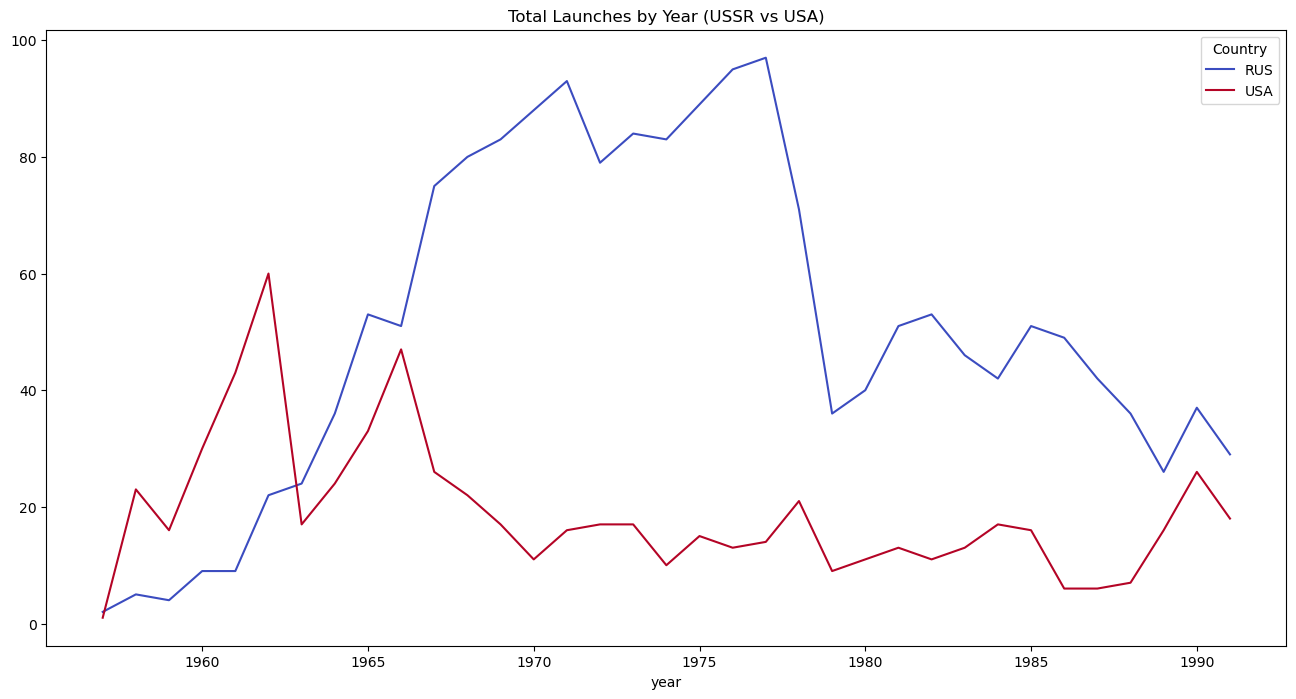

In [411]:
cold_war_launch_by_year.plot(
    figsize = (16,8),
    title = 'Total Launches by Year (USSR vs USA)',
    colormap = 'coolwarm'
)

As can be seen the USSR conducts more space missions than the USA overall.

In [365]:
cold_war_mission_failures_by_year = ussr_vs_usa[ussr_vs_usa['Mission_Status']!='Success'].groupby(['year', 'Country'])['Mission_Status'].count().unstack(level=1)
cold_war_mission_failures_by_year.fillna(0, inplace=True)
cold_war_mission_failures_by_year

Country,RUS,USA
year,,
1957,0.00,1.00
1958,4.00,18.00
1959,2.00,10.00
1960,6.00,14.00
1961,4.00,16.00
1962,7.00,10.00
1963,8.00,4.00
1964,7.00,5.00
1965,6.00,7.00


<Axes: title={'center': 'Total Mission Failures by Year (USSR vs USA)'}, xlabel='year'>

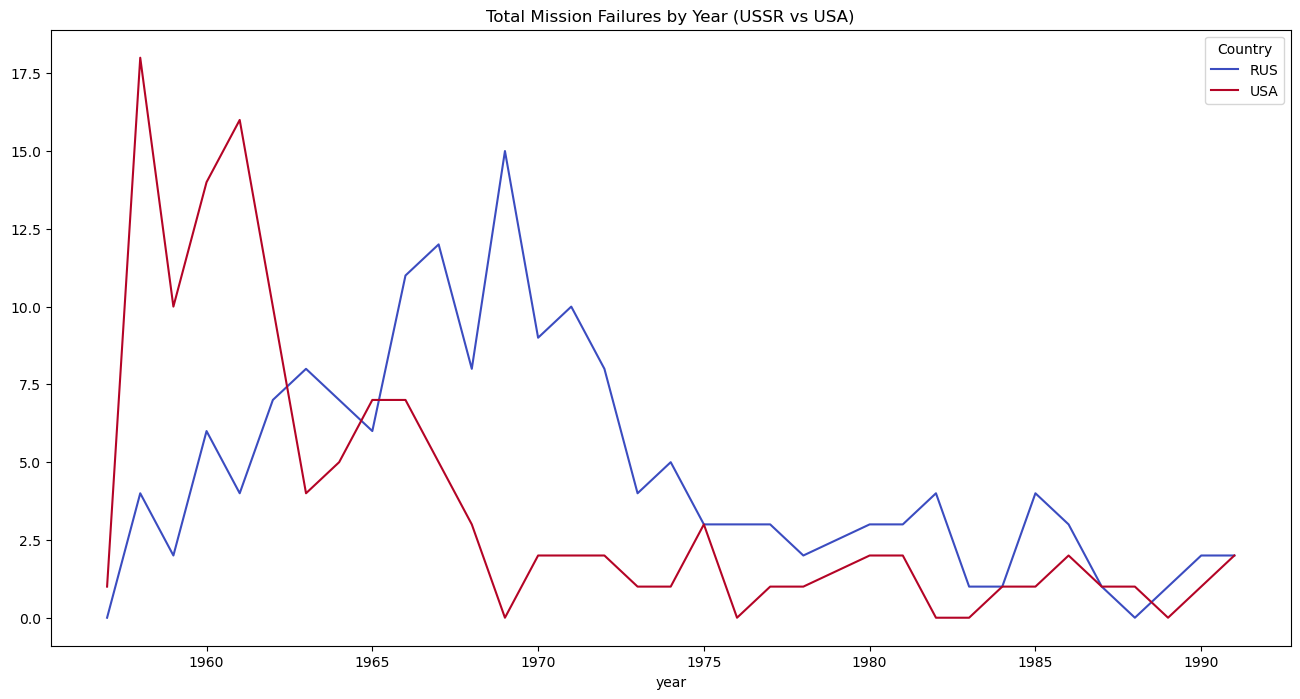

In [407]:
cold_war_mission_failures_by_year.plot(
    figsize = (16,8),
    title = 'Total Mission Failures by Year (USSR vs USA)',
    colormap='coolwarm'
)

With more launches comes more opportunity for the mission to be a failure as can be seen from the chart above. the USSR had significantly more failed misions than the USA more the majority of the space race. 

In [413]:
cold_war_failpct_by_year = cold_war_mission_failures_by_year/cold_war_launch_by_year * 100
cold_war_failpct_by_year.fillna(0, inplace=True)
cold_war_failpct_by_year

Country,RUS,USA
year,,
1957,0.00,100.00
1958,80.00,78.26
1959,50.00,62.50
1960,66.67,46.67
1961,44.44,37.21
1962,31.82,16.67
1963,33.33,23.53
1964,19.44,20.83
1965,11.32,21.21


<Axes: title={'center': 'Mission Failure Percentage by Year (USSR vs USA)'}, xlabel='year'>

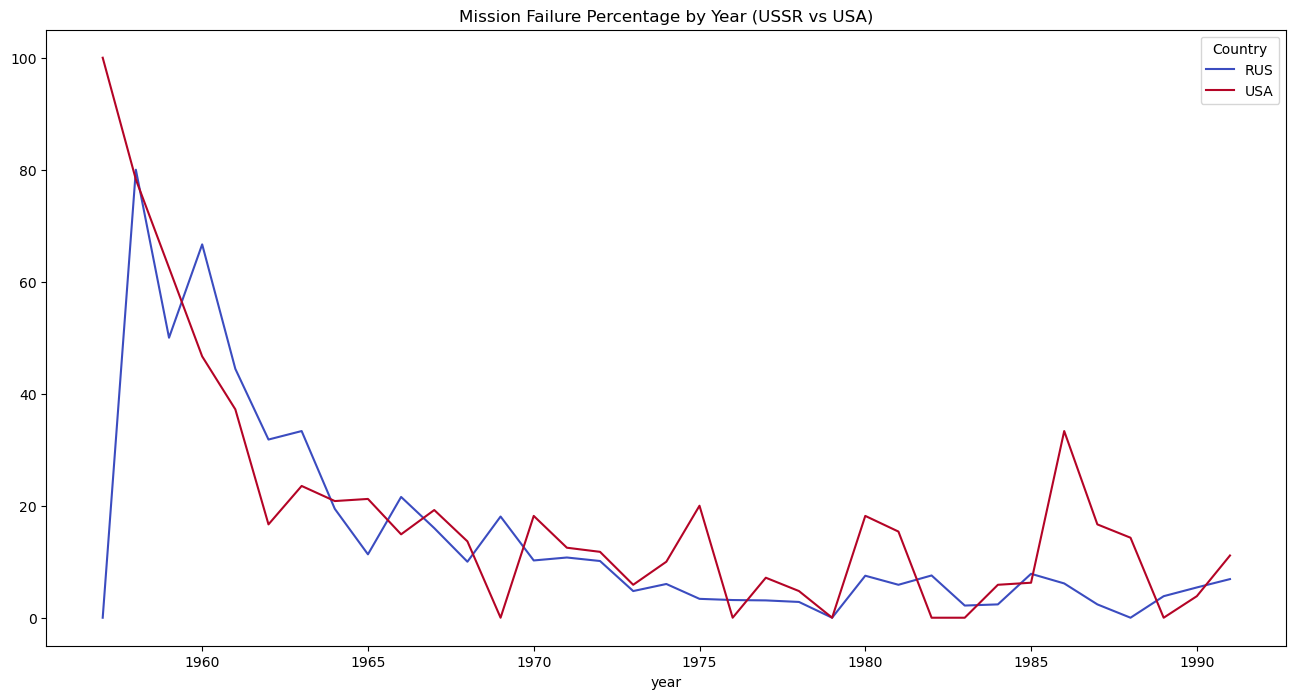

In [415]:
cold_war_failpct_by_year.plot(
    figsize = (16,8),
    title = 'Mission Failure Percentage by Year (USSR vs USA)',
    colormap='coolwarm'
)

In [417]:
launches_by_country_per_year = df.groupby(['year', 'Country'])['Mission_Status'].count().unstack(level=1)
launches_by_country_per_year.fillna(0, inplace=True)
launches_by_country_per_year

Country,AUS,BRA,CHN,FRA,IND,IRN,ISR,JPN,KEN,KOR,"Korea, Democratic Peoples Republic of",NZL,Pacific Ocean,RUS,USA
year,,,,,,,,,,,,,,,
1957,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,1.00
1958,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,23.00
1959,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,16.00
1960,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,9.00,30.00
1961,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,9.00,43.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,0.00,0.00,22.00,11.00,7.00,0.00,1.00,4.00,0.00,0.00,1.00,0.00,0.00,17.00,27.00
2017,0.00,0.00,18.00,11.00,5.00,1.00,0.00,7.00,0.00,0.00,0.00,1.00,0.00,19.00,30.00
2018,0.00,0.00,39.00,11.00,7.00,0.00,0.00,6.00,0.00,0.00,0.00,3.00,0.00,17.00,34.00


<Axes: title={'center': 'Number of Launches by Country over the Years'}, xlabel='year'>

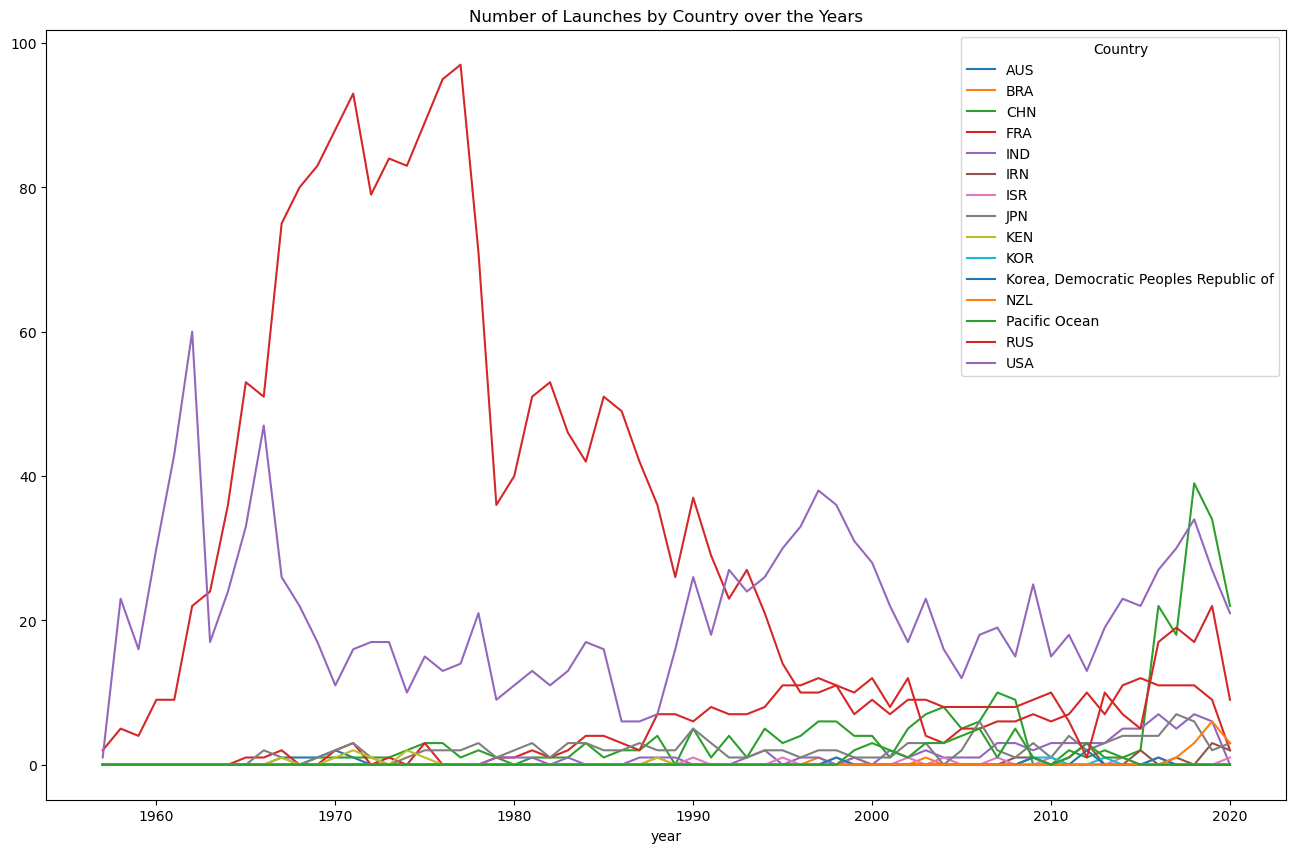

In [419]:
launches_by_country_per_year.plot(
    title = 'Number of Launches by Country over the Years',
    figsize = (16,10),
)

- Between the years 1957 to mid 1960's and mid 1990's to mid 2010's, the leading country in the space race in terms of number of launches is USA.
- Between the mid 1960s and mid 1990s, the leading country in the space race in terms of number of launches is the Russian Federation.
- From mid 2010-2020, the leading country in the space race in terms of number of launches is China.

In [421]:
launches_by_organisation_per_year = df.groupby(['year', 'Organisation'])['Mission_Status'].count().unstack(level=1)
launches_by_organisation_per_year.fillna(0, inplace=True)
launches_by_organisation_per_year

Organisation,AEB,AMBA,ASI,Arianespace,Arm??e de l'Air,Blue Origin,Boeing,CASC,CASIC,CECLES,...,SpaceX,Starsem,ULA,US Air Force,US Navy,UT,VKS RF,Virgin Orbit,Yuzhmash,i-Space
year,,,,,,,,,,,,,,,,,,,,,
1957,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
1958,0.00,7.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,2.00,12.00,0.00,0.00,0.00,0.00,0.00
1959,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,10.00,4.00,0.00,0.00,0.00,0.00,0.00
1960,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00
1961,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,23.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,0.00,0.00,0.00,11.00,0.00,4.00,0.00,22.00,0.00,0.00,...,9.00,0.00,12.00,0.00,0.00,0.00,4.00,0.00,0.00,0.00
2017,0.00,0.00,0.00,11.00,0.00,1.00,0.00,16.00,1.00,0.00,...,18.00,0.00,8.00,0.00,0.00,0.00,6.00,0.00,0.00,0.00
2018,0.00,0.00,0.00,11.00,0.00,2.00,0.00,37.00,0.00,0.00,...,21.00,0.00,8.00,0.00,0.00,0.00,5.00,0.00,0.00,0.00


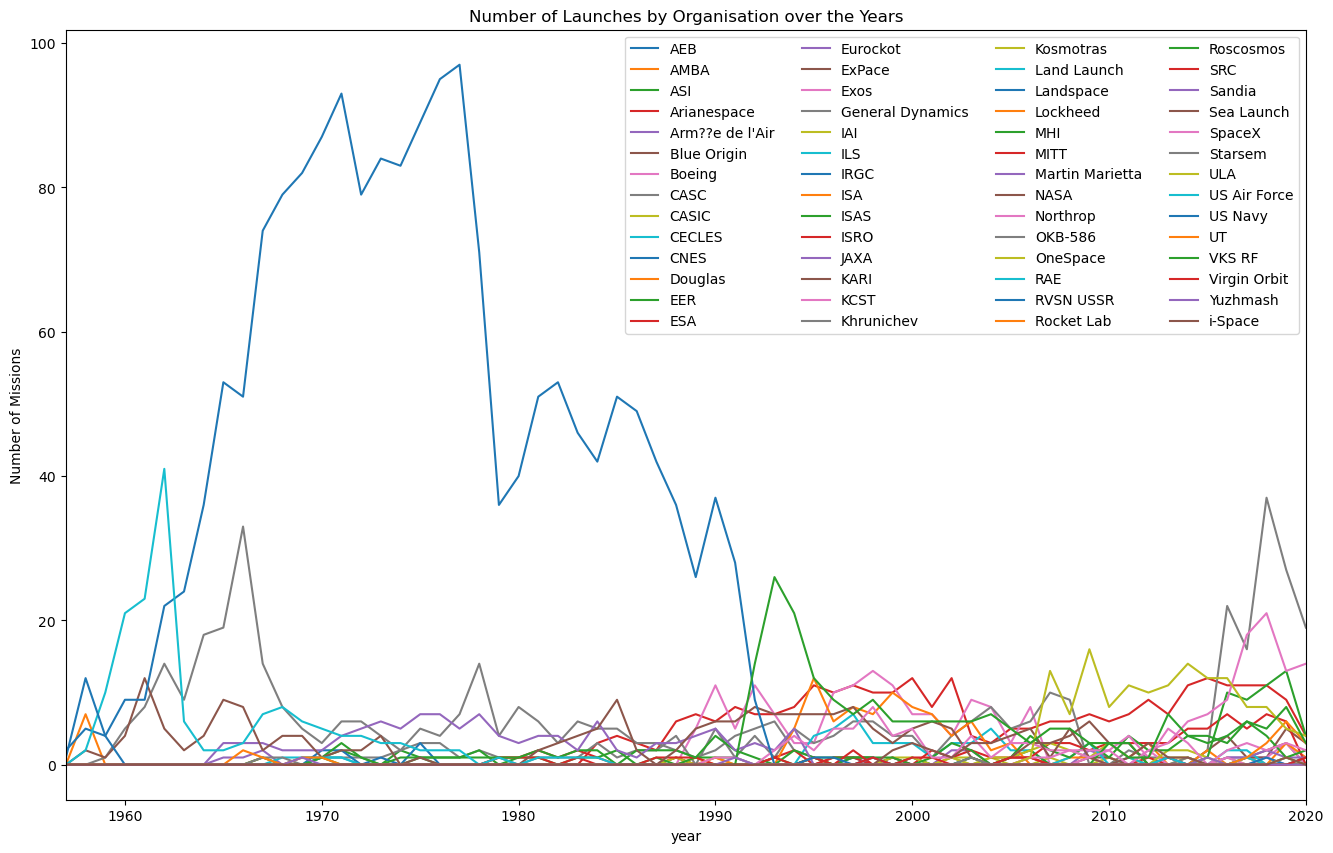

In [423]:
launches_by_organisation_per_year.plot(
    title = 'Number of Launches by Organisation over the Years',
    figsize = (16,10),
)

plt.ylabel('Number of Missions')
plt.xlim(1957, 2020)
plt.legend(loc="upper right", ncol=4)
plt.show()

As we can see there are many organisation competing in the space race and while the USSR was historically dominant the have fallen behind in the past several decades with CASC taking the lead in recent years.